### Pruebo ajustar gaussiana a datos

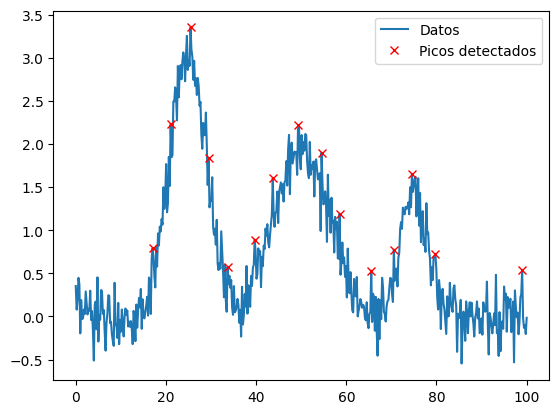

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 9200.

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# --- Función suma de gaussianas ---
def multi_gauss(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i:i+3]
        y += A * np.exp(-(x-mu)**2 / (2*sigma**2))
    return y

# --- Datos sintéticos con 3 gaussianas ---
np.random.seed(0)
x = np.linspace(0, 100, 500)
y = (3*np.exp(-(x-25)**2/(2*4**2)) +
     2*np.exp(-(x-50)**2/(2*6**2)) +
     1.5*np.exp(-(x-75)**2/(2*3**2)) +
     0.2*np.random.normal(size=len(x)))

# --- Detección de picos ---
peaks, _ = find_peaks(y, height=0.5, distance=20)  # "distance" evita picos muy juntos
plt.plot(x, y, label="Datos")
plt.plot(x[peaks], y[peaks], "rx", label="Picos detectados")
plt.legend()
plt.show()

# --- Parámetros iniciales (A, mu, sigma) para cada pico ---
p0 = []
for peak in peaks:
    A_init = y[peak]         # altura estimada
    mu_init = x[peak]        # posición estimada
    sigma_init = 5           # ancho inicial "aprox"
    p0 += [A_init, mu_init, sigma_init]

# --- Ajuste ---
popt, pcov = curve_fit(multi_gauss, x, y, p0=p0)

# --- Graficar resultados ---
plt.scatter(x, y, s=5, label="Datos")
plt.plot(x, multi_gauss(x, *popt), 'r-', label="Ajuste total")

# Graficar cada gaussiana individual
for i in range(0, len(popt), 3):
    A, mu, sigma = popt[i:i+3]
    plt.plot(x, A*np.exp(-(x-mu)**2/(2*sigma**2)), '--', label=f"Pico en {mu:.1f}")

plt.legend()
plt.show()

### Pruebo

/tmp/ipykernel_1204518/2016954816.py:18: RuntimeWarning: overflow encountered in exp
  return a1*np.exp(-(x-mu1)**2/sigma1) + a2*np.exp(-(x-mu2)**2/sigma2) + a3*np.exp(-(x-mu3)**2/sigma3)
/tmp/ipykernel_1204518/2016954816.py:18: RuntimeWarning: overflow encountered in multiply
  return a1*np.exp(-(x-mu1)**2/sigma1) + a2*np.exp(-(x-mu2)**2/sigma2) + a3*np.exp(-(x-mu3)**2/sigma3)


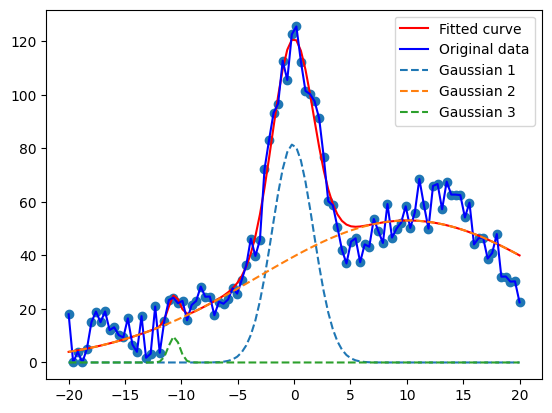

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# --- Multi-gaussian plot of sample data ---

# create data points
x = np.linspace(-20,20,100)

# y = y1 + y2 + noise
y = 10*np.exp(-(x+8)**2/15) + 100*np.exp(-(x-0)**2/10) + 50*np.exp(-(x-12)**2/80) + np.random.randint(0,20,x.size)

# define function
def multi_gauss(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3):
    return a1*np.exp(-(x-mu1)**2/sigma1) + a2*np.exp(-(x-mu2)**2/sigma2) + a3*np.exp(-(x-mu3)**2/sigma3)

def gauss(x,a,mu,sigma):
    return a*np.exp(-(x-mu)**2/sigma)

# do fitting
p_ini=[100, 0, 10, 50, 5, 100, 20, -8, 15] # initial guess
popt, pcov = curve_fit(multi_gauss, x, y, p0=p_ini)

# plot fitted curve
y_fit = multi_gauss(x, *popt)
plt.plot(x,y_fit, color='red', label='Fitted curve')
plt.plot(x, y, color='blue', label='Original data')

plt.plot(x, gauss(x, *popt[:3]), '--', label='Gaussian 1')
plt.plot(x, gauss(x, *popt[3:6]), '--', label='Gaussian 2')
plt.plot(x, gauss(x, *popt[6:]), '--', label='Gaussian 3')

plt.scatter(x,y)
plt.savefig(f'./output/prueba_ajuste.png', dpi=300)
plt.legend()
plt.show()

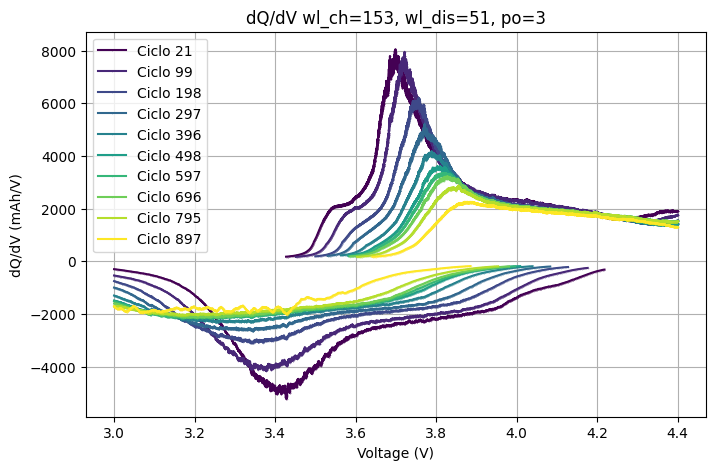

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...\n        }\n"

In [3]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
import func_deriv as func_deriv
import func_plots as func_plots

# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]

# %% ------- Ajustar picos ------------------------------------------------------------

# Primero trunco datos
    # charge (wl = 153, truncar los n=30 puntos iniciales)
    # discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)

diccio =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...
        }
'''
# Exportar a csv para trabajar en Origin
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)


[8.24582325e+02 3.55926227e+00 2.05769399e-03 3.43122502e+03
 3.69480676e+00 2.19306001e-03 2.89305266e+03 3.74241321e+00
 1.29627209e-02 2.19822736e+03 4.02348023e+00 3.28873199e-01]


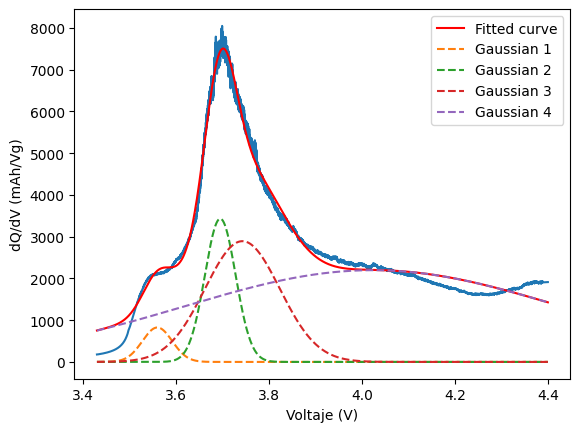

In [4]:
df_ch = diccio[21]['Ch']
df_dis = diccio[21]['Dis']

dvdq_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dvdq_ch_calc)

def multi_gauss(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3, a4, mu4, sigma4):
    return a1*np.exp(-(x-mu1)**2/sigma1) + a2*np.exp(-(x-mu2)**2/sigma2) + a3*np.exp(-(x-mu3)**2/sigma3) + a4*np.exp(-(x-mu4)**2/sigma4)

def gauss(x,a,mu,sigma):
    return a*np.exp(-(x-mu)**2/sigma)

# do fitting
p_ini=[2000, 3.55, 0.01, 7500, 3.71, 0.01, 5000, 3.775, 0.01, 2300, 4.0, 0.1] # initial guess

popt = p_ini

#plt.plot(V, gauss(V, *popt[:3]), '--', label='Gaussian 1')
#plt.plot(V, gauss(V, *popt[3:6]), '--', label='Gaussian 2')
#plt.plot(V, gauss(V, *popt[6:9]), '--', label='Gaussian 3')
#plt.plot(V, gauss(V, *popt[9:]), '--', label='Gaussian 4')

popt, pcov = curve_fit(multi_gauss, V, dvdq_ch_calc, p0=p_ini)

# plot fitted curve
y_fit = multi_gauss(V, *popt)
plt.plot(V,y_fit, color='red', label='Fitted curve')

plt.plot(V, gauss(V, *popt[:3]), '--', label='Gaussian 1')
plt.plot(V, gauss(V, *popt[3:6]), '--', label='Gaussian 2')
plt.plot(V, gauss(V, *popt[6:9]), '--', label='Gaussian 3')
plt.plot(V, gauss(V, *popt[9:]), '--', label='Gaussian 4')

print(popt)

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos_4picos.png', dpi=300)
#plt.xlim(3,4.5)


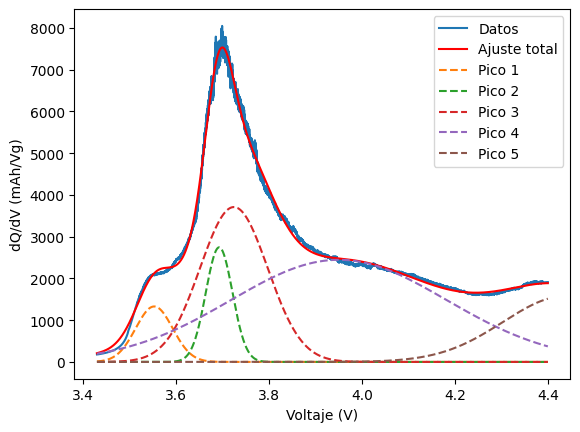

In [14]:
def multi_gauss(x, *params):
    """
    params: [a1, mu1, sigma1, a2, mu2, sigma2, ..., an, mun, sigman]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        a, mu, sigma = params[i:i+3]
        y += a * np.exp(-(x-mu)**2 / (2*sigma**2))
    return y

def gauss(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2 / (2*sigma**2))


p_ini = [
    800, 3.55, 0.002,   # pico 1
    #1500, 3.61, 0.004,  # pico 2 (nuevo intermedio)
    3400, 3.69, 0.002,  # pico 3
    2900, 3.74, 0.013,  # pico 4
    1100, 4.0, 0.02,   # pico 5 (nuevo intermedio)
    2200, 4.39, 0.1    # pico 6
]

n_peaks = len(p_ini) // 3

# lower bounds (a > 0, sigma > 0, mu libre)
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lb += [0, mu0-0.05, 1e-6]      # amplitud >=0, mu +- tolerancia, sigma > 0
    ub += [np.inf, mu0+0.05, np.inf]

bounds = (lb, ub)

# Ajuste
popt, pcov = curve_fit(multi_gauss, V, dvdq_ch_calc, p0=p_ini, bounds=bounds)

# Curva total ajustada
y_fit = multi_gauss(V, *popt)
plt.plot(V, dvdq_ch_calc, label="Datos")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 3):
    a, mu, sigma = popt[i:i+3]
    plt.plot(V, gauss(V, a, mu, sigma), '--', label=f"Pico {i//3 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos.png', dpi=300)
plt.show()